<a href="https://colab.research.google.com/github/RileyWClarke/fftpca_note/blob/master/FFTPCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FFTPCA with ZTF Continuous Readout Mode Data

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA

In [2]:
#Making Figures look nice
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12

In [55]:
#from google.colab import drive
#drive.mount("/content/gdrive")

## Reading in Data

In [96]:
fluxes = np.load('Data/ztf_crm/testlcs_c05.npy')
fluxes

array([[-1.48872297, -1.43363141, -2.13309826, ..., -1.70942861,
        -2.07220809, -0.32925794],
       [ 0.00487791, -0.61172058, -0.18108485, ..., -0.51464273,
        -1.47783968, -0.97541531],
       [ 0.91907088,  0.50013929,  1.02403783, ..., -2.02687819,
        -1.69468884, -1.43621357],
       ...,
       [ 1.19293671,  1.45452958,  1.41919454, ..., -0.5224115 ,
        -0.64466773, -0.52515827],
       [-1.54582113, -1.56805156, -1.77345031, ...,  1.39642497,
         1.64800323,  2.15542427],
       [ 1.49098707, -0.44030954,  0.16615015, ...,  0.71198729,
         0.44547342, -1.04654389]], shape=(10, 3080))

# FFT Filtering

In [50]:
def invgaussian(a ,m, s, x):
    g = -a * np.exp(-(m-x)**2 / s**2) + 1 
    return g

In [51]:
def bandpass_ifft(flux, low_cutoff, high_cutoff, sample=1, inv_box=False, gf_sig = 1, Filter='box', Plot=''):
    """Bandpass filtering on a real signal using inverse FFT
    
    Inputs
    =======
    
    X: 1-D numpy array of floats, the real time domain signal (time series) to be filtered
    Low_cutoff: float, frequency components below this frequency will not pass the filter (physical frequency in unit of Hz)
    High_cutoff: float, frequency components above this frequency will not pass the filter (physical frequency in unit of Hz)
    sample: float, the sampling frequency of the signal (physical frequency in unit of Hz)    
    inv_box: If using box filter, setting inv=True filters out frequencies outside the box
    Filter: Default filter is box, can choose 'Gaussian' also
    
    Notes
    =====
    1. The input signal must be real, not imaginary nor complex
    2. The Filtered_signal will have only half of original amplitude. Use abs() to restore. 
    3. In Numpy/Scipy, the frequencies goes from 0 to F_sample/2 and then from negative F_sample to 0. 
    
    """        
    #perform fft
    spectrum = np.fft.rfft(flux) 
    freq = np.fft.rfftfreq(len(flux), sample)
    
    #calculate the index of the cut off points
    lc = np.abs(freq) < low_cutoff
    hc = np.abs(freq) > high_cutoff
    between = ~(lc + hc)
    
    ps = np.abs(spectrum)**2
    if ('PS' in Plot) or ('All' in Plot):
      plt.plot(freq, ps)
      plt.title("power spectrum")
      plt.xlabel('Frequency (1/day)')
      plt.ylabel('Power Spectral Density')
      #plt.xlim(0,100)
      #plt.savefig('Figures/spec.png', bbox_inches='tight', pad_inches=0.5)
      plt.show()

    if ('DFT' in Plot) or ('All' in Plot):
      plt.plot(freq, spectrum)
      #plt.plot(freq[between], spectrum[between], alpha=0.5)
      plt.title("real fourier transform ")
      plt.xlabel('Frequency (1/day)')
      plt.ylabel('Amplitude')
      #plt.xlim(0,100)
      #plt.savefig('Figures/fft.png', bbox_inches='tight', pad_inches=0.5)
      plt.show()
    
    
    
    if Filter == 'box':
    
      #filtered_spectrum = spectrum.copy()
    
      if inv_box == True:
        x_1 = np.arange(0, low_cutoff, 0.1)
        x_2 = np.arange(high_cutoff, np.max(freq), 0.1)
        plt.plot(freq, spectrum)
        plt.fill_between(x_1, [plt.ylim()[0]] * len(x_1), 
                     [plt.ylim()[1]] * len(x_1), color='r', alpha=0.3)
        plt.fill_between(x_2, [plt.ylim()[0]] * len(x_2), 
                     [plt.ylim()[1]] * len(x_2), color='r', alpha=0.3)
        plt.title("range to suppress")
        plt.figure()
        filtered_spectrum[lc] = 0.
        filtered_spectrum[hc] = 0.
      else:
        x_ = np.arange(low_cutoff, high_cutoff, 0.1)
        plt.plot(freq, spectrum)
        plt.fill_between(x_, [plt.ylim()[0]] * len(x_), 
                     [plt.ylim()[1]] * len(x_), color='r', alpha=0.3)
        plt.title("range to suppress")
        plt.figure()
        filtered_spectrum[between] = 0.
    
    if Filter == 'Gaussian':
      ig = invgaussian(1, np.median([low_cutoff,high_cutoff]), gf_sig, freq)
      filtered_spectrum = spectrum * ig
      if ('filter' in Plot) or ('All' in Plot):
        plt.plot(freq, ig)
        plt.title('Gaussian Filter')
        #plt.savefig('Figures/gfilter.png')
        #plt.xlim(0,100)
        plt.figure()

    if ('spec_filtered' in Plot) or ('All' in Plot):
      plt.plot(freq, filtered_spectrum, label="filtered spectrum")
      plt.plot(freq, spectrum, c='k', ls="--", label="spectrum", alpha=0.5)
      plt.title("Unfiltered vs. Filtered Spectrum")
      plt.xlabel('Frequency (1/day)')
      plt.ylabel('Amplitude')
      #plt.xlim(0,100)
      #plt.savefig('Figures/filter_compare.png', bbox_inches='tight', pad_inches=0.5)
      plt.figure()

    filtered_signal = np.fft.irfft(filtered_spectrum)  # Construct filtered signal

    if ('signal_filtered' in Plot) or ('All' in Plot):
      fig = plt.figure(figsize=(15,10)) 
      plt.plot(t, filtered_signal, label="filtered signal")
      plt.plot(t, flux, c='k', ls="--", label="original signal", alpha=0.5)
      plt.xlabel('Time')
      plt.ylabel('Amplitude')
      plt.title("Unfiltered vs. Filtered Signal")
      #plt.savefig('Figures/filtered_signal.png', bbox_inches='tight', pad_inches=0.5)
      plt.legend()
      #Filtered_signal = np.zeros_like(Filtered_signal)
    return spectrum, freq, filtered_spectrum, filtered_signal, low_cutoff, high_cutoff

In [97]:
dfts = []
pspectra = []
for i, flux in enumerate(fluxes):
    lco, hco = 4, 6
    sample_rate = 300 #Hz
    Spectrum, frequency, Filtered_spectrum, Filtered_signal, Low_freq, High_freq = bandpass_ifft(flux=flux, low_cutoff=lco, high_cutoff=hco, sample=1./sample_rate, gf_sig = 1, Filter='Gaussian')

    dfts.append(Spectrum)
    pspectra.append(np.abs(Spectrum)**2)

# PCA with Spectra

In [98]:
pspec_dict = {}

for j, spec in enumerate(pspectra):
  pspec_dict["spec{0}".format(j)] = spec[1:]

pspec_df = pd.DataFrame(data=pspec_dict)

In [99]:
pspec_df.head()

,spec0,spec1,spec2,spec3,spec4,spec5,spec6,spec7,spec8,spec9
0,10412.818617,52012.234914,10841.610979,859698.920659,47343.428344,15036.054624,11266.949985,273282.519615,330325.884823,48826.052490
1,15743.301745,17618.063382,8676.770547,225645.573780,156735.249514,78731.345395,227726.492600,338115.983012,287674.440658,35623.790624
2,89358.220401,6697.151704,7352.554412,421300.720384,8092.878255,98696.500764,43796.831228,4340.601462,414985.459241,64420.436750
3,41995.276999,86196.627863,8210.952606,48103.373876,20725.479359,94691.737168,52229.753196,82878.878352,17602.779636,41649.240078
4,58530.507321,10769.848517,18094.154031,77082.228761,100252.939661,4892.450078,26160.657466,169660.446687,27250.304702,1056.645894


In [100]:
x = pspec_df.values
x = scale(x, axis=0)

In [101]:
pca = PCA()

pca.fit(x)

X = pca.transform(x)

pca_df = pd.DataFrame(data = X)
print(pca_df.shape)
pca_df

(1540, 10)


,0,1,2,3,4,5,6,7,8,9
0,25.685367,26.673030,5.150933,3.422091,4.211301,-9.214829,3.970514,-7.991232,1.186985,-2.125997
1,31.140209,13.211327,-10.836231,-4.524369,-5.155371,10.136504,1.903910,3.050940,-1.427426,1.839673
2,23.112589,11.627926,13.558636,9.282191,3.548294,2.195251,-5.118727,6.731535,-4.600284,1.066016
3,13.697110,-2.963146,3.716953,-5.292721,1.000008,4.241142,-4.642916,0.176885,5.020210,-1.237748
4,11.000428,1.087083,-5.755340,0.349140,4.851805,1.073965,6.445257,1.083972,4.033174,1.246056
...,...,...,...,...,...,...,...,...,...,...
1535,-0.616769,0.283971,-0.014862,0.061160,-0.047948,-0.021291,-0.058481,-0.001140,-0.086234,0.143973
1536,-0.559323,0.094701,0.158497,-0.002856,-0.003168,-0.035457,0.014040,-0.027185,0.007698,0.037516
1537,-0.529739,0.254055,-0.059310,-0.005681,-0.085097,-0.033963,-0.024678,0.023572,-0.007873,0.006292
1538,-0.565353,0.196889,0.051853,0.028638,-0.033528,0.009876,-0.031065,0.046429,-0.002599,0.075051


## Bandpass Filtering First 2 Components

In [102]:
def gaussian(a, m, s, x):
    g = a * np.exp(-(m-x)**2 / s**2) 
    return g

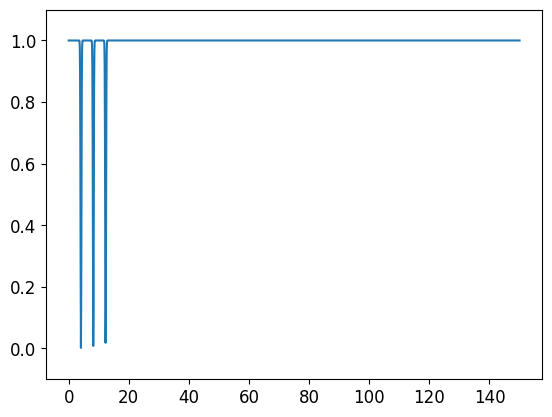

In [103]:
def hrm_gfilter(x, s, fund, nhrm=0, amps=np.ones(len(x))):

  fhrms = np.array([fund])

  for i in range(2, nhrm+2):
    fhrms = np.append(fhrms, i*fund)

  filt = np.ones(len(x))

  for hrm, amp in zip(fhrms, amps):
    filt *= invgaussian(amp,hrm,s,x) 
   # filt += gaussian(amp,hrm,s,x)

  return filt

filt = hrm_gfilter(frequency, 0.2, 4.1, 2)

plt.plot(frequency, filt)
plt.ylim(-0.1,1.1);

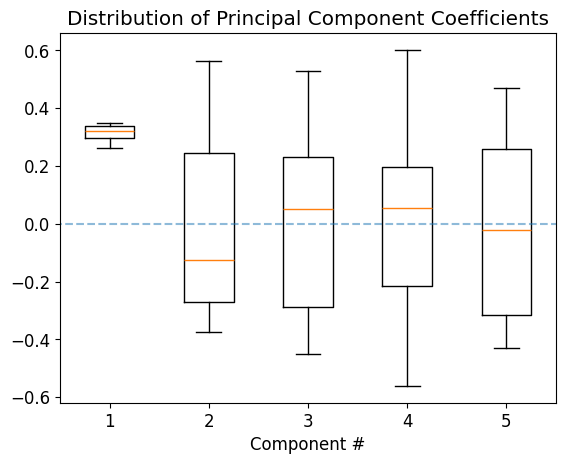

In [104]:
# Multiple box plots on one Axes
fig, ax = plt.subplots()
ax.boxplot([pca.components_[0], pca.components_[1], pca.components_[2], pca.components_[3],pca.components_[4]])
plt.hlines(0, 0, 7, linestyle='--', alpha=0.5)
plt.xlabel('Component #')
plt.title('Distribution of Principal Component Coefficients')
plt.xlim(0.5,5.5)
plt.savefig('Figures/ztfcrm_box.png', dpi=100, bbox_inches='tight')
plt.show()

Peak at 77.33766233766234 Hz


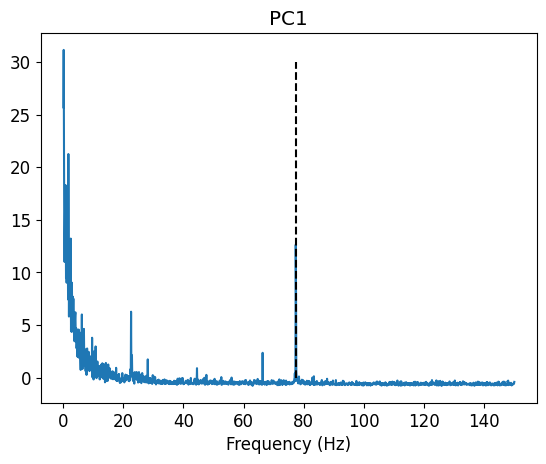

In [105]:
plt.plot(frequency[1:], pca_df.iloc[:,0])
plt.vlines(frequency[41:][np.argmax(pca_df.iloc[40:,0])], 0, 30, color='k', ls='--')
print(f'Peak at {frequency[41:][np.argmax(pca_df.iloc[40:,0])]} Hz')
plt.title('PC1')
plt.xlabel('Frequency (Hz)')
plt.savefig('Figures/ztfcrm_pc1.png', dpi=100, bbox_inches='tight')

In [106]:
d = {'pc1':pca.components_[0],'pc2':pca.components_[1],'pc3':pca.components_[2],'pc4':pca.components_[3],'pc5':pca.components_[4]}
coeff_df = pd.DataFrame(data=d)
coeff_df.to_csv('Data/ztfcrm_coeffs.csv')

# PCA with DFTs

In [107]:
dft_dict = {}

for j, dft in enumerate(dfts):
  dft_dict["dft{0}".format(j)] = dft

dft_df = pd.DataFrame(data=dft_dict)

In [108]:
y = dft_df.values
y.real = scale(y.real, axis=0)
y.imag = scale(y.imag, axis=0)

In [109]:
print(y[:,0].real.mean(), y[:,0].imag.mean())

1.3832759294486052e-17 3.7463723089233055e-18


In [110]:
print(y[:,0].real.std(), y[:,0].imag.std())

1.0 0.9999999999999998


In [111]:
pca2 = PCA()

pca2.fit(y.real)

Y = pca2.transform(y.real)

pca2_df = pd.DataFrame(data = Y)
print(pca2_df.shape)


pca2i = PCA()

pca2i.fit(y.imag)

Yi = pca2i.transform(y.imag)

pca2i_df = pd.DataFrame(data = Yi)
print(pca2i_df.shape)

(1541, 10)
(1541, 10)


## Bandpass Filtering ALL Components

In [ ]:
def pc_thr(dataframe, frequency, fund, threshold):
  '''
  Identifies PCs with significant power at a given fundamental frequency
  Inputs:
    dataframe: pandas DataFrame of PCA components (PCs are rows)
    frequency: numpy array of frequencies corresponding to the PCA components
    fund: float, fundamental frequency to check for significant power
    threshold: float, multiplier for standard deviation to define significance
  Outputs:
    pc_list: list of indices of PCs with significant power at the fundamental frequency
  '''
  pcs = dataframe.values
  pc_list = []
  f_ind = np.argmin(np.abs(frequency - fund))
  fstep = np.diff(frequency).mean()
  std = 0.1
  pts_per_std = int(std/fstep)

  for i, pc in enumerate(pcs):
   
    local_avg = np.mean(np.concatenate((pc[(f_ind - pts_per_std*2):(f_ind - pts_per_std*1)], 
                       pc[(f_ind + pts_per_std*1):(f_ind + pts_per_std*2)])))
    local_std = np.std(np.concatenate((pc[(f_ind - pts_per_std*2):(f_ind - pts_per_std*1)], 
                       pc[(f_ind + pts_per_std*1):(f_ind + pts_per_std*2)])))

    if np.abs(pc[f_ind]) > np.abs( local_avg * threshold * local_std ):
 
      pc_list.append(i)

    else:
      pass

  return pc_list

In [113]:
ss = pc_thr(pca2_df.T, frequency, fund=77.34, threshold=2)
len(ss)

4

In [173]:
### BANDPASS FILTERING PCs

def pc_filt(dataframe, frequency, fund, std, nhrms, subset=None, plot=False):

  '''
  Takes a set of Discrete Fourier Transform PCs with a common frequency domain 
  and bandpass filters them on a given 
  fundamental frequency and associated harmonics
  with a Gaussian filter of standard deviation "std"
  '''

  #Create pcs and new_pcs
  new_pcs = []
  pcs = dataframe.values

  #Select subset of pcs if applicable:
  if subset != None:
    pcs = np.take(pcs, subset, axis=0)
  else:
    pass

  #Bandpass filter pcs:
  for i, pc in enumerate(pcs):

    fstep = np.diff(frequency).mean()
    pts_per_std = int(std/fstep)
    dftpc = np.copy(pc)  
    hrm_inds = []

    for i in range(1,nhrms+2):
      hrm_inds.append(np.where(np.abs(frequency - fund*i) == np.abs(frequency - fund*i).min())[0][0])


    for k, ind in enumerate(hrm_inds):
      local_avg = np.mean(np.concatenate((dftpc[(ind - pts_per_std*2):(ind - pts_per_std*1)], 
                       dftpc[(ind + pts_per_std*1):(ind + pts_per_std*2)])))

      dftpc[5:] -= local_avg
      dftpc[5:] *= hrm_gfilter(frequency[5:], std, fund*(k+1))
      dftpc[5:] += local_avg

    new_pcs.append(dftpc)

  #Replace modified pcs in the ensemble
  if subset != None:
    prod = dataframe.values.copy()
    for n, m in zip(range(len(subset)), subset):
      prod[m] = new_pcs[n]
    return prod
  
  if plot:
    plt.plot(frequency, pcs[0], label='Original PC1')
    plt.plot(frequency, new_pcs[0], label='Filtered PC1')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title('PC1 (Imaginary) Before and After Filtering')
    plt.legend()
    plt.show()

  return np.array(new_pcs)

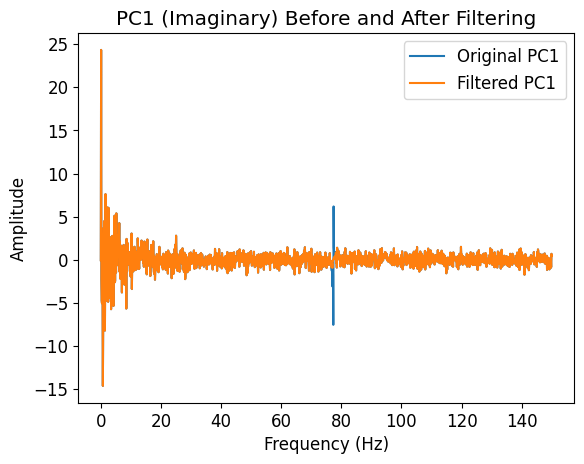

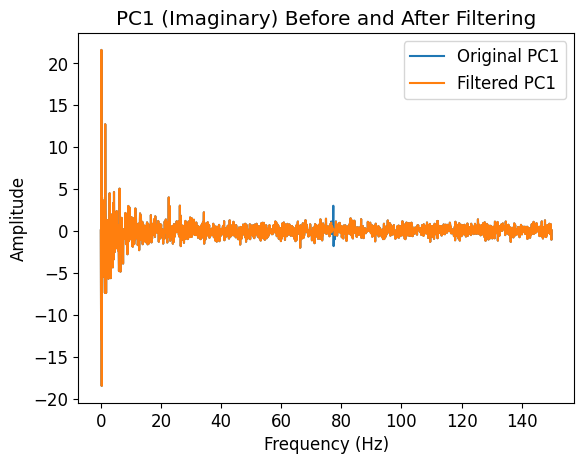

In [174]:
fundamental = 77.34  #Hz
nComp=10 #Selects how many comps to use

real_new_pcs = pc_filt(pca2_df.T, frequency, fund=fundamental, std=0.5, nhrms=2, subset=None, plot=True)
im_new_pcs = pc_filt(pca2i_df.T, frequency, fund=fundamental, std=0.5, nhrms=2, subset=None, plot=True)

Yhat = np.dot(real_new_pcs.T[:,0:nComp], pca2.components_[0:nComp,:])
Yhati = np.dot(im_new_pcs.T[:,0:nComp], pca2i.components_[0:nComp,:])

Yhat1c = Yhat + (1j)*Yhati

processed = []

for i in range(nComp):
  processed.append(np.fft.irfft(Yhat1c[:,i]))

processed = np.array(processed)

np.save(f'Data/ztfcrm_processed_lcs_{nComp}pc', processed)

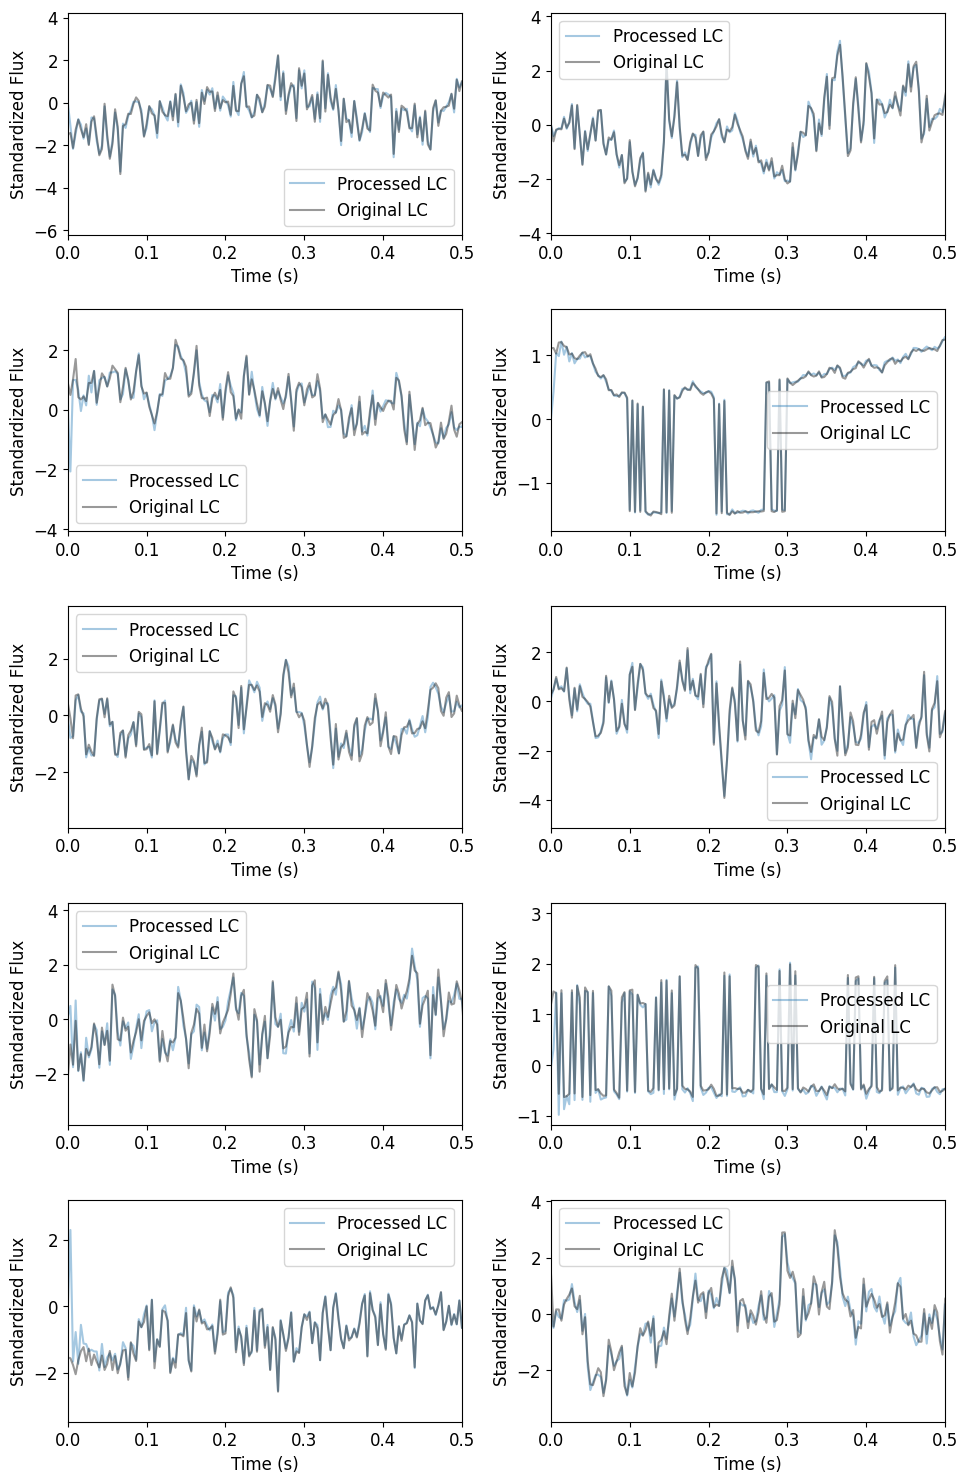

In [169]:
fig, ax = plt.subplots(5,2, figsize=(10,15))
axes = ax.flatten()

for i in range(10):
    x = np.arange(0,len(fluxes[i,:])) / 300
    axes[i].plot(x, processed[i,:] / processed[i,:].std(axis=0), color='C0', alpha=0.4, label='Processed LC')
    axes[i].plot(x, fluxes[i,:], color='k', alpha=0.4, label='Original LC')
    axes[i].set_xlim(0,0.5)
    axes[i].set_ylabel('Standardized Flux')
    axes[i].set_xlabel('Time (s)')
    axes[i].legend()

plt.tight_layout()